In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


C:\Users\icc\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    r"C:\Users\icc\Downloads\training_set\training_set",
    target_size=(128, 128),   # 🔥 increased image size
    batch_size=32,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    r"C:\Users\icc\Downloads\test_set\test_set",
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary'
)

# Check labels (VERY IMPORTANT)
print("Class Labels:", train_generator.class_indices)

Found 8005 images belonging to 2 classes.
Found 2023 images belonging to 2 classes.
Class Labels: {'cats': 0, 'dogs': 1}


In [3]:
cnn = Sequential()

# Layer 1
cnn.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
cnn.add(MaxPooling2D(pool_size=(2,2)))

# Layer 2
cnn.add(Conv2D(64, (3,3), activation='relu'))
cnn.add(MaxPooling2D(pool_size=(2,2)))

# Layer 3
cnn.add(Conv2D(128, (3,3), activation='relu'))
cnn.add(MaxPooling2D(pool_size=(2,2)))

# Flatten
cnn.add(Flatten())

# Fully Connected Layer
cnn.add(Dense(128, activation='relu'))
cnn.add(Dropout(0.5))
cnn.add(Dense(64, activation='relu'))
# Output Layer
cnn.add(Dense(1, activation='sigmoid'))

# Compile
cnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

cnn.summary()


C:\Users\icc\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       3,211,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,312,961 (12.64 MB)

 Trainable params: 3,312,961 (12.64 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:
early_stop = EarlyStopping(monitor='val_loss', patience=3)

history = cnn.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=20,
    validation_data=test_generator,
    validation_steps=test_generator.samples // test_generator.batch_size,
    callbacks=[early_stop]
)


Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 150s 587ms/step - accuracy: 0.5478 - loss: 0.6823 - val_accuracy: 0.5982 - val_loss: 0.6544
Epoch 2/20
  1/250 ━━━━━━━━━━━━━━━━━━━━ 1:44 421ms/step - accuracy: 0.6562 - loss: 0.6636

C:\Users\icc\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


250/250 ━━━━━━━━━━━━━━━━━━━━ 12s 45ms/step - accuracy: 0.6562 - loss: 0.6636 - val_accuracy: 0.6076 - val_loss: 0.6490
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 141s 563ms/step - accuracy: 0.6594 - loss: 0.6216 - val_accuracy: 0.7133 - val_loss: 0.5624
Epoch 4/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 20s 80ms/step - accuracy: 0.7188 - loss: 0.6294 - val_accuracy: 0.7207 - val_loss: 0.5570
Epoch 5/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 144s 574ms/step - accuracy: 0.7182 - loss: 0.5668 - val_accuracy: 0.7450 - val_loss: 0.5097
Epoch 6/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 11s 43ms/step - accuracy: 0.7188 - loss: 0.5691 - val_accuracy: 0.7475 - val_loss: 0.5145
Epoch 7/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 141s 564ms/step - accuracy: 0.7542 - loss: 0.5092 - val_accuracy: 0.7728 - val_loss: 0.4755
Epoch 8/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 11s 44ms/step - accuracy: 0.7188 - loss: 0.4764 - val_accuracy: 0.7669 - val_loss: 0.4820
Epoch 9/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 150s 599ms/step - accuracy: 0.7658 - loss: 0.4867 - val

In [5]:
cnn.history.history

{'accuracy': [0.5478489995002747,
  0.65625,
  0.6593503355979919,
  0.71875,
  0.7181738615036011,
  0.71875,
  0.754170298576355,
  0.71875,
  0.7658346891403198,
  0.75,
  0.7864041328430176,
  0.71875,
  0.7950583100318909,
  0.78125,
  0.8078514933586121,
  0.84375,
  0.8280446529388428,
  0.90625,
  0.8261632919311523,
  0.90625],
 'loss': [0.6822898983955383,
  0.6636390686035156,
  0.6216449737548828,
  0.6294494867324829,
  0.5667849779129028,
  0.569068968296051,
  0.5092397332191467,
  0.47643449902534485,
  0.4867165684700012,
  0.47054481506347656,
  0.45688340067863464,
  0.43667683005332947,
  0.4339207708835602,
  0.5248998403549194,
  0.4106309711933136,
  0.3973483145236969,
  0.3935607373714447,
  0.26983097195625305,
  0.3914109766483307,
  0.2530934512615204],
 'val_accuracy': [0.5982142686843872,
  0.6076388955116272,
  0.7132936716079712,
  0.7207341194152832,
  0.745039701461792,
  0.747519850730896,
  0.7728174328804016,
  0.766865074634552,
  0.800099194049835

In [6]:
Train_accuracy=cnn.history.history["accuracy"]
Test_accuracy=cnn.history.history["val_accuracy"]

In [7]:
len(Test_accuracy)

20

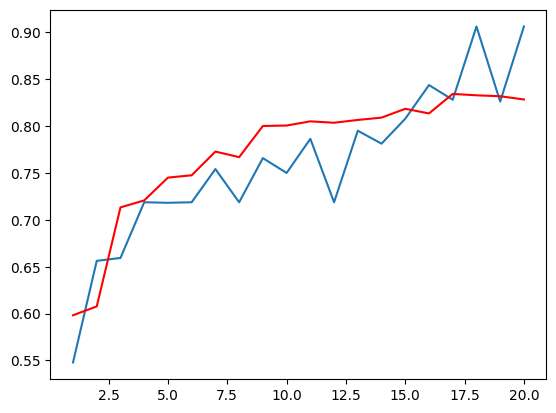

In [8]:
import matplotlib.pyplot as plt
plt.plot([i for i in range(1,21)],Train_accuracy)
plt.plot([i for i in range(1,21)],Test_accuracy, c = "red")
plt.show()

In [9]:
cnn.save("dog_cat_model.h5")

In [10]:
import numpy as np
from tensorflow.keras.preprocessing import image

test_image = image.load_img(
    r"C:\Users\icc\Downloads\training_set\training_set\cats\cat.945.jpg",
    target_size=(128, 128)
)

test_image = image.img_to_array(test_image)
test_image = np.expand_dims(test_image, axis=0)
test_image = test_image / 255.0

result = cnn.predict(test_image)

if result[0][0] > 0.5:
    print("Dog 🐶")
else:
    print("Cat 🐱")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step
Cat 🐱
